## 1) Inspiration

I found this dataset interesting because flight delays impact many individuals who rely on air travel. Having grown up in Texas, I travel back home frequently to visit family and have personally experienced the inconvenience of these delays. There have been moments where, to get the most reasonably priced flight, my flights are scheduled to land with just enough time for me to make it to my classes later in the day. With flight delays, however, it can make it difficult to make it to Northwestern's campus in Evanston from the airport in time. For many people who travel for work, flight delays can also make it difficult to meet professional commitments.

As a business minor, I am interested in pursuing similar analytical work in the future, which makes this dataset especially interesting for this project. This dataset includes two different csv files for flight delay information: one from January 2019 and another from January 2020. I felt that this structure was great for this predictive analysis project because I will be able to use the 2019 data to train my model and then test it on the 2020 data to see its accuracy. I hope to use the insights from this project to better understand the factors that contribute to flight delays and to inform more efficient scheduling practices.

## 2) Stakeholders

The stakeholders for this project are primarily airlines, airports, and business analysts in the aviation industry. Airlines may be interested in learning how to improve flight scheduling and assigning shifts for crews. Airports may be interested in learning how to improve congestion to avoid future flight delays. Business analysts may be interested in learning how to improve operations and any systematic delay factors.

## 3) Task and Metrics

1) This is a classification problem. My goal in this project is to predict if a flight will be delayed or not (1=Yes, 0=No).
2) `ARR_DEL15` is my response variable since I am attempting to predict if a flight will be delayed. The predictors that I will be using are:
   - `DISTANCE`
   - `DAY_OF_WEEK` to see how delays fluctuate throughout the month
   - `OP_UNIQUE_CARRIER` and `ORIGIN` to see if any carriers, airports, or origins are more likely to have delayed flights.
3) I am planning to exclude `TAIL_NUM` because it is unique to each aircraft and unnecessary for prediction. I am also planning to exclude `OP_CARRIER_FL_NUM` because it also serves as an identifier.
4) I am going to evaluate the prediction performance of my model by using the 2019 data as my training data and the 2020 dataset as the test data. This will be able to show how accurate my predictions are and compare them against the subsequent year. It is important to note that the 2020 COVID-19 pandemic occurred in March 2020, so flights were not as affected in January. Some of the metrics that I will use for this classification project are accuracy (if classes are balanced), ROC-AUC, precision/recall, and the confusion matrix. Accuracy is a measure of the proportion of correct predictions out of all predictions. The AUC measures how well the model separates the two classes across all possible classification thresholds. Precision is a measure of the proportion of positive cases that were actually positive. Recall is a measure of the proportion of the actual positive cases that were accurately predicted. The confusion matrix will allow me to visualize FP, TP, FN, and TN.

## 4) Data


**Identifying the Data Source:**
- This dataset was sourced from Kaggle via this page: https://www.kaggle.com/datasets/divyansh22/flight-delay-prediction?resource=download&select=Jan_2019_ontime.csv 
- The original data was collected from the Bureau of Transportation Statistics and open-sourced under U.S. Govt. Works.
- There are two datasets under this Kaggle page: one containing data from 2019 and the other containing data from 2020.
- Each observation in each dataset contains a flight in the month of January in the United States.

**About the Data**
- There are 583,985 observations in the dataset. Each observation is a U.S. flight in the month of January.
- There are 22 variables in the dataset
- The unnamed column will most likely be removed, so there are 21 meaningful columns
- The continuous variables are:
    - Departure Time (`DEP_TIME`) in hhmm
    - Arrival Time (`ARR_TIME`) in hhmm
    - Distance (`DISTANCE`) in miles between airports
- The discrete numeric variables (categorical) are:
    - Day of the Month (`DAY_OF_MONTH`)
    - Day of the Week (`DAY_OF_WEEK`)
- The categorical variables to be used as identifiers are:
    - `OP_UNIQUE_CARRIER`
    - `OP_CARRIER_AIRLINE_ID`
    - `OP_CARRIER`
    - `TAIL_NUM`
    - `OP_CARRIER_FL_NUM`
    - `ORIGIN_AIRPORT_ID`
    - `ORIGIN_AIRPORT_SEQ_ID`
    - `ORIGIN`
    - `DEST_AIRPORT_ID`
    - `DEST_AIRPORT_SEQ_ID`
    - `DEST`
    - `DEP_TIME_BLK`
- The binary categorical variables (Yes/No) are:
    - Departure Delay Indicator, 15 Minutes or More (1=Yes, 0=No) (`DEP_DEL15`)
    - Arrival Delay Indicator (`ARR_DEL15`)
    - Cancellations (`CANCELLED`)
    - Diversions (`DIVERTED`)

**Predictors and Response**

The response variable is the arrival delay indicator (`ARR_DEL15`), while the predictors are the flight characteristics known beforehand, such as departure time, distance, day of week/month, airline carrier, origin and destination airports, and departure time block.

**Data Cleaning**

Are there any missing values? Will cleaning/imputing be necessary?
- There are nulls in the tail_num, dep_time, dep_del15, arr_time, arr_del15, and the unnamed column
- The unnamed column was dropped
- `TAIL_NUM` is an aircraft identifier. It is not necessary for this project, so it can be dropped
- `DEP_TIME`,`DEP_DEL15`,`ARR_DEL15`,`ARR_TIME` are all valuable components for predictive analysis
  - There are usually nulls when flights were cancelled or diverted; therefore, it is not necessary to impute (see code below)
  - If one of these variables is used as the target variable, the nulls will need to be dropped since it's not possible to impute for cancelled/diverted flights

Is there any substantial correlation between the variables?
- Using train.corr(numeric_only=True), the strongest correlation was between `ARR_TIME` and DEP_TIME with a value of around 0.67
    - However, this correlation may be misleading because of the cyclical nature of time. A higher arr_time does not indicate that there will be a higher departure time. It depends entirely on the difference between flights and the distance of the flight.
    - Other than this observation, most other correlation values are below 0.05.

## 5) Prediction

In [2]:
#| echo: false
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# More tools here -- for lower-level implementation of cross-validation

# Three functions for cross-validation
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.model_selection import cross_val_score, cross_val_predict, cross_validate
from sklearn.linear_model import Ridge, Lasso, LogisticRegression, LinearRegression
from sklearn.linear_model import RidgeCV, LassoCV, LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score,roc_auc_score, precision_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error,mean_absolute_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_recall_curve, roc_curve, auc

#### Developing the Linear and Unregularized Model

For this type of data, I decided to use logistic regression to build a classification model that would use `ARR_DEL15` as the response variable. However, remaining 20 variables, I chose 5 that I believed would be most meaningful to the project based on their correlation with other variables and common sense. The first variable that I chose as my predictor was `DEP_TIME_BLK`. There were a couple of variables that measured time in the dataset (`DEP_TIME`,`DEP_DEL15`,`ARR_DEL15`,`ARR_TIME`), however, these are often cyclical and may not have a distinct relationship with the response variable. For example, flight delays tend to cluster during peak travel periods, such as early morning or late evening, rather than increasing steadily throughout the day. Therefore, using the categorical time block variable `DEP_TIME_BLK` allowed me to capture these nonlinear patterns more effectively than using a continuous time variable by implementing the one-hot-encoding technique.

The second predictor I chose to implement in my model was `DISTANCE`. This was a decision made with common sense rather than with correlation values. Flights with a longer distance between airports are more sensitive to small issues. Weather, airplane malfunctions, or any issues with air traffic control in the airspace between airports can cause a longer flight to be delayed rather than a short one.

The third predictor I chose to implement in my model was `DAY_OF_WEEK`. Travel patterns naturally fluctuate throughout the week, with higher passenger volumes on certain days. For example, many working-class travelers fly on Fridays and Mondays to return home for the weekend or to be in town for the workweek. Busier airports on these peak days are more likely to experience delays, making `DAY_OF_WEEK` a meaningful predictor for flight delays.

The fourth predictor I chose to implement was `ORIGIN`. Living in Chicago, I felt that this predictor could provide strong insight into whether or not a flight would be delayed. For example, ORD tends to delay or cancel flights quite often because of snow, wind, etc., compared to an airport with milder weather.

The final predictor I chose to implement was `OP_UNIQUE_CARRIER`. This predictor identifies the specific airline operating the flight. I was curious to see if certain airlines tend to have an effect on flight delays more than others. For example, Spirit is an airline that tends to have quite a few delays historically.

**Analysis:**
Below is a table that displays the training and test performances after adding each predictor. 
- Accuracy: Accuracy remains consistent across all models. Roughly 86.2–86.3% for train and around 81.4% for test.
- Recall: Recall is 0.00 for Models 1-3 and starts increasing at Model 4. Early models fail to identify any delayed flights. Adding ORIGIN and ORIGIN + other categorical predictors allows the model to catch a few delays, but recall is still extremely low. This is consistent with the idea that this is a largely imbalanced dataset. Delays are rare, and most flights are on time.
- Precision: Test precision is lower than train precision, which indicates overfitting, especially for categorical predictors like ORIGIN.
- AUC: AUC improves slightly when more predictors are added. Still, these are low AUC values, indicating the model’s ability to discriminate between delayed and on-time flights is limited.

In [3]:
#| echo: false
# Data Cleaning:
train = pd.read_csv('Jan_2019_ontime.csv')
train = train.drop(columns = 'Unnamed: 21')
train = train.drop(columns = 'TAIL_NUM')
train = train[(train["CANCELLED"] == 0.0) & (train["DIVERTED"] == 0.0)] #only keeps flights that were not diverted or cancelled

test = pd.read_csv('Jan_2020_ontime.csv')
test = test.drop(columns = 'Unnamed: 21')
test = test.drop(columns = 'TAIL_NUM')
test = test[(test["CANCELLED"] == 0.0) & (test["DIVERTED"] == 0.0)]

In [4]:
#| echo: false
# Building the model with raw DEP_TIME_BLK

# One-hot predictor -- do not need to scale with OHE
X_train = pd.get_dummies(train['DEP_TIME_BLK'], drop_first=True)
X_test = pd.get_dummies(test['DEP_TIME_BLK'], drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

y_train = train['ARR_DEL15']
y_test = test['ARR_DEL15']

# Logistic model
logreg = LogisticRegression(penalty = None)
logreg.fit(X_train, y_train)
# Predictions
y_pred_test = logreg.predict(X_test)
y_pred_train = logreg.predict(X_train)
y_prob_test = logreg.predict_proba(X_test)[:,1]
y_prob_train = logreg.predict_proba(X_train)[:,1]

# Metrics
test_acc_1 = accuracy_score(y_test, y_pred_test)*100
train_acc_1 = accuracy_score(y_train, y_pred_train)*100
test_rec_1 = recall_score(y_test, y_pred_test)*100
train_rec_1 = recall_score(y_train, y_pred_train)*100
test_prec_1 = precision_score(y_test, y_pred_test,zero_division=0)*100
train_prec_1 = precision_score(y_train, y_pred_train,zero_division=0)*100
test_auc_1 = roc_auc_score(y_test, y_prob_test)
train_auc_1 = roc_auc_score(y_train, y_prob_train)

In [5]:
#| echo: false
# Let's add another predictor: DISTANCE

X_train_time = pd.get_dummies(train['DEP_TIME_BLK'], drop_first=True)
X_test_time = pd.get_dummies(test['DEP_TIME_BLK'], drop_first=True)
X_test_time = X_test_time.reindex(columns=X_train_time.columns, fill_value=0)

# add DISTANCE
X_train = pd.concat([X_train_time, train[['DISTANCE']]], axis=1)
X_test = pd.concat([X_test_time, test[['DISTANCE']]], axis=1)

y_train = train['ARR_DEL15']
y_test = test['ARR_DEL15']

# Scale
scaler = StandardScaler()
scaler.fit(X_train) 
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
logreg = LogisticRegression(penalty = None,max_iter = 1000)
logreg.fit(X_train_scaled, y_train)

# Predict
# Predictions
y_pred_test = logreg.predict(X_test_scaled)
y_pred_train = logreg.predict(X_train_scaled)
y_prob_test = logreg.predict_proba(X_test_scaled)[:,1]
y_prob_train = logreg.predict_proba(X_train_scaled)[:,1]

# Metrics
test_acc_2 = accuracy_score(y_test, y_pred_test)*100
train_acc_2 = accuracy_score(y_train, y_pred_train)*100
test_rec_2 = recall_score(y_test, y_pred_test)*100
train_rec_2 = recall_score(y_train, y_pred_train)*100
test_prec_2 = precision_score(y_test, y_pred_test,zero_division=0)*100
train_prec_2 = precision_score(y_train, y_pred_train,zero_division=0)*100
test_auc_2 = roc_auc_score(y_test, y_prob_test)
train_auc_2 = roc_auc_score(y_train, y_prob_train)

In [6]:
#| echo: false
# ADD DAY_OF_THE_WEEK -- need to OHE
day_train = pd.get_dummies(train['DAY_OF_WEEK'], drop_first=True)
day_test = pd.get_dummies(test['DAY_OF_WEEK'], drop_first=True)
day_test = day_test.reindex(columns=day_train.columns, fill_value=0)

X_train = pd.concat([X_train_time, day_train, train[['DISTANCE']]], axis=1)
X_test = pd.concat([X_test_time, day_test, test[['DISTANCE']]], axis=1)

X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

y_train = train['ARR_DEL15']
y_test = test['ARR_DEL15']

# Scale
scaler = StandardScaler()
scaler.fit(X_train) 
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
logreg = LogisticRegression(penalty = None,max_iter = 1000)
logreg.fit(X_train_scaled, y_train)

# Predict
y_pred_test = logreg.predict(X_test_scaled)
y_pred_train = logreg.predict(X_train_scaled)
y_prob_test = logreg.predict_proba(X_test_scaled)[:,1]
y_prob_train = logreg.predict_proba(X_train_scaled)[:,1]

# Performance
test_acc_3 = accuracy_score(y_test, y_pred_test)*100
train_acc_3 = accuracy_score(y_train, y_pred_train)*100
test_rec_3 = recall_score(y_test, y_pred_test)*100
train_rec_3 = recall_score(y_train, y_pred_train)*100
test_prec_3 = precision_score(y_test, y_pred_test,zero_division=0)*100
train_prec_3 = precision_score(y_train, y_pred_train,zero_division=0)*100
test_auc_3 = roc_auc_score(y_test, y_prob_test)
train_auc_3 = roc_auc_score(y_train, y_prob_train)

In [7]:
#| echo: false
# Add ORIGIN as a predictor -- also need to OHE
time_train = pd.get_dummies(train['DEP_TIME_BLK'], drop_first=True)
time_test = pd.get_dummies(test['DEP_TIME_BLK'], drop_first=True)
time_test = time_test.reindex(columns=time_train.columns, fill_value=0)
day_train = pd.get_dummies(train['DAY_OF_WEEK'].astype(str), drop_first=True)
day_test = pd.get_dummies(test['DAY_OF_WEEK'].astype(str), drop_first=True)
day_test = day_test.reindex(columns=day_train.columns, fill_value=0)
origin_train = pd.get_dummies(train['ORIGIN'], drop_first=True)
origin_test = pd.get_dummies(test['ORIGIN'], drop_first=True)
origin_test = origin_test.reindex(columns=origin_train.columns, fill_value=0)

X_train = pd.concat([time_train, day_train, origin_train, train[['DISTANCE']]], axis=1)
X_test = pd.concat([time_test, day_test, origin_test, test[['DISTANCE']]], axis=1)

# make column names consistent for sklearn
X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

# TARGET
y_train = train['ARR_DEL15']
y_test = test['ARR_DEL15']

# SCALE
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# MODEL
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_scaled, y_train)

# PREDICT
y_pred_test = logreg.predict(X_test_scaled)
y_pred_train = logreg.predict(X_train_scaled)
y_prob_test = logreg.predict_proba(X_test_scaled)[:,1]
y_prob_train = logreg.predict_proba(X_train_scaled)[:,1]

# PERFORMANCE
test_acc_4 = accuracy_score(y_test, y_pred_test)*100
train_acc_4 = accuracy_score(y_train, y_pred_train)*100
test_rec_4 = recall_score(y_test, y_pred_test)*100
train_rec_4 = recall_score(y_train, y_pred_train)*100
test_prec_4 = precision_score(y_test, y_pred_test,zero_division=0)*100
train_prec_4 = precision_score(y_train, y_pred_train,zero_division=0)*100
test_auc_4 = roc_auc_score(y_test, y_prob_test)
train_auc_4 = roc_auc_score(y_train, y_prob_train)


In [8]:
#| echo: false
# Add ORIGIN and OP_UNIQUE_CARRIER as predictors -- also need to OHE
time_train = pd.get_dummies(train['DEP_TIME_BLK'], drop_first=True)
time_test = pd.get_dummies(test['DEP_TIME_BLK'], drop_first=True)
time_test = time_test.reindex(columns=time_train.columns, fill_value=0)
day_train = pd.get_dummies(train['DAY_OF_WEEK'].astype(str), drop_first=True)
day_test = pd.get_dummies(test['DAY_OF_WEEK'].astype(str), drop_first=True)
day_test = day_test.reindex(columns=day_train.columns, fill_value=0)
origin_train = pd.get_dummies(train['ORIGIN'], drop_first=True)
origin_test = pd.get_dummies(test['ORIGIN'], drop_first=True)
origin_test = origin_test.reindex(columns=origin_train.columns, fill_value=0)
carrier_train = pd.get_dummies(train['OP_UNIQUE_CARRIER'], drop_first=True)
carrier_test = pd.get_dummies(test['OP_UNIQUE_CARRIER'], drop_first=True)
carrier_test = carrier_test.reindex(columns=carrier_train.columns, fill_value=0)
X_train = pd.concat([time_train, day_train, origin_train, carrier_train, train[['DISTANCE']]], axis=1)
X_test = pd.concat([time_test, day_test, origin_test, carrier_test, test[['DISTANCE']]], axis=1)
# make column names consistent for sklearn
X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)
# TARGET
y_train = train['ARR_DEL15']
y_test = test['ARR_DEL15']
# SCALE
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
# MODEL
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_scaled, y_train)
# PREDICT
y_pred_test = logreg.predict(X_test_scaled)
y_pred_train = logreg.predict(X_train_scaled)
y_prob_test = logreg.predict_proba(X_test_scaled)[:,1]
y_prob_train = logreg.predict_proba(X_train_scaled)[:,1]
# PERFORMANCE
test_acc_5 = accuracy_score(y_test, y_pred_test)*100
train_acc_5 = accuracy_score(y_train, y_pred_train)*100
test_rec_5 = recall_score(y_test, y_pred_test)*100
train_rec_5 = recall_score(y_train, y_pred_train)*100
test_prec_5 = precision_score(y_test, y_pred_test,zero_division=0)*100
train_prec_5 = precision_score(y_train, y_pred_train,zero_division=0)*100
test_auc_5 = roc_auc_score(y_test, y_prob_test)
train_auc_5 = roc_auc_score(y_train, y_prob_train)

In [9]:
#| echo: false
results_df = pd.DataFrame({
    'Model': [1, 2, 3, 4, 5],
    'Predictors': [
        'DEP_TIME_BLK',
        'DEP_TIME_BLK, DAY_OF_WEEK',
        'DEP_TIME_BLK, DAY_OF_WEEK, DISTANCE',
        'DEP_TIME_BLK, DAY_OF_WEEK, DISTANCE, ORIGIN',
        'DEP_TIME_BLK, DAY_OF_WEEK, DISTANCE, ORIGIN, OP_UNIQUE_CARRIER'
    ],
    'Test Accuracy':   [test_acc_1,  test_acc_2,  test_acc_3,  test_acc_4,  test_acc_5],
    'Train Accuracy':  [train_acc_1, train_acc_2, train_acc_3, train_acc_4, train_acc_5],
    'Test Recall':     [test_rec_1,  test_rec_2,  test_rec_3,  test_rec_4,  test_rec_5],
    'Train Recall':    [train_rec_1, train_rec_2, train_rec_3, train_rec_4, train_rec_5],
    'Test Precision':  [test_prec_1, test_prec_2, test_prec_3, test_prec_4, test_prec_5],
    'Train Precision': [train_prec_1,train_prec_2,train_prec_3,train_prec_4,train_prec_5],
    'Test AUC':        [test_auc_1,  test_auc_2,  test_auc_3,  test_auc_4,  test_auc_5],
    'Train AUC':       [train_auc_1, train_auc_2, train_auc_3, train_auc_4, train_auc_5]
})

results_df.set_index('Model')

,Predictors,Test Accuracy,Train Accuracy,Test Recall,Train Recall,Test Precision,Train Precision,Test AUC,Train AUC
Model,,,,,,,,,
1,DEP_TIME_BLK,86.269082,81.408325,0.000000,0.000000,0.000000,0.000000,0.562716,0.574665
2,"DEP_TIME_BLK, DAY_OF_WEEK",86.269082,81.408325,0.000000,0.000000,0.000000,0.000000,0.563696,0.575358
3,"DEP_TIME_BLK, DAY_OF_WEEK, DISTANCE",86.269082,81.408325,0.000000,0.000000,0.000000,0.000000,0.549411,0.581080
4,"DEP_TIME_BLK, DAY_OF_WEEK, DISTANCE, ORIGIN",86.259236,81.407442,0.044966,0.043717,27.819549,47.422680,0.560901,0.630621
5,"DEP_TIME_BLK, DAY_OF_WEEK, DISTANCE, ORIGIN, O...",86.245553,81.405675,0.085070,0.100739,24.911032,46.696035,0.568751,0.642733


**Visualization:**
I also used the data presented in the table above to construct four separate plots to visualize how the different train and test performance metrics changed across the models. The analyses explained previously are more visible in these plots. Overall, the results suggest that adding more predictors slightly improves the model’s ability to identify delayed flights, but the improvements are limited and highlight challenges related to class imbalance.

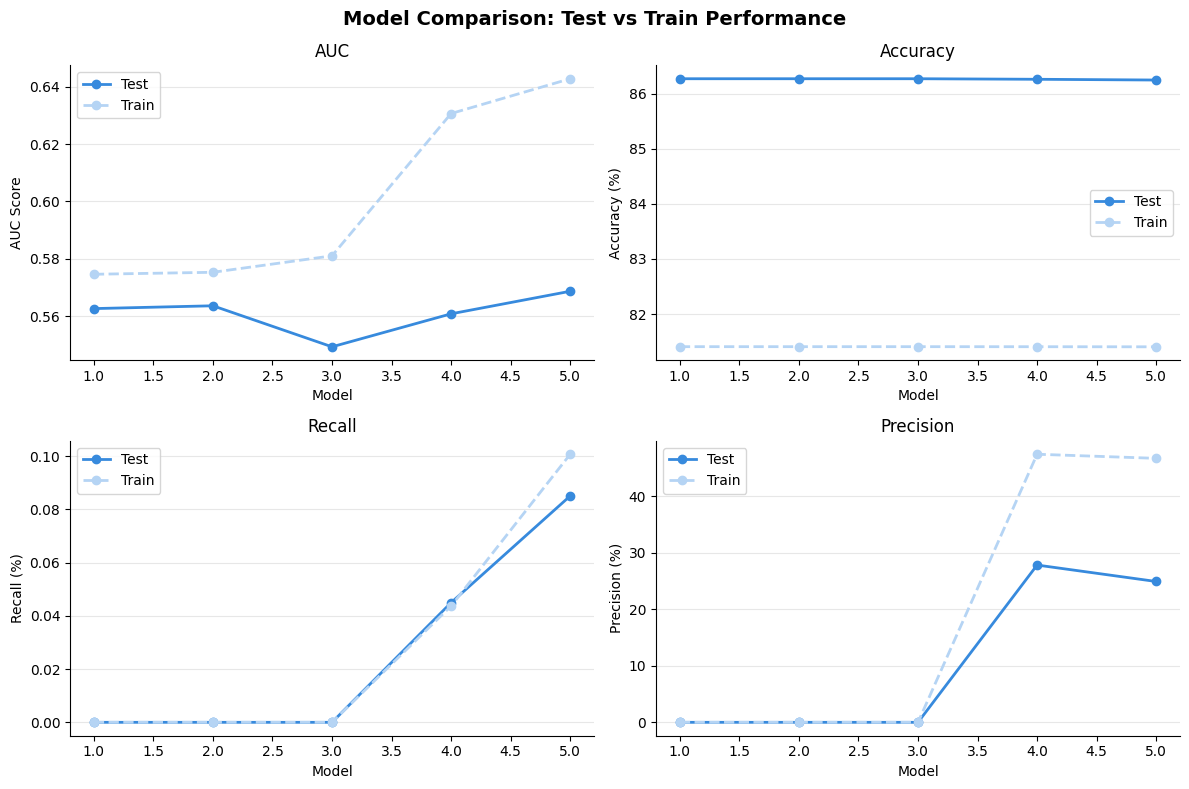

In [10]:
#| echo: false
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# AUC
axes[0,0].plot(results_df['Model'], results_df['Test AUC'],  marker='o', label='Test',  color='#378ADD', linewidth=2)
axes[0,0].plot(results_df['Model'], results_df['Train AUC'], marker='o', label='Train', color='#B5D4F4', linewidth=2, linestyle='--')
axes[0,0].set_title('AUC')
axes[0,0].set_xlabel('Model')
axes[0,0].set_ylabel('AUC Score')
axes[0,0].legend()
axes[0,0].grid(axis='y', alpha=0.3)
axes[0,0].spines[['top', 'right']].set_visible(False)

# Accuracy
axes[0,1].plot(results_df['Model'], results_df['Test Accuracy'],  marker='o', label='Test',  color='#378ADD', linewidth=2)
axes[0,1].plot(results_df['Model'], results_df['Train Accuracy'], marker='o', label='Train', color='#B5D4F4', linewidth=2, linestyle='--')
axes[0,1].set_title('Accuracy')
axes[0,1].set_xlabel('Model')
axes[0,1].set_ylabel('Accuracy (%)')
axes[0,1].legend()
axes[0,1].grid(axis='y', alpha=0.3)
axes[0,1].spines[['top', 'right']].set_visible(False)

# Recall
axes[1,0].plot(results_df['Model'], results_df['Test Recall'],  marker='o', label='Test',  color='#378ADD', linewidth=2)
axes[1,0].plot(results_df['Model'], results_df['Train Recall'], marker='o', label='Train', color='#B5D4F4', linewidth=2, linestyle='--')
axes[1,0].set_title('Recall')
axes[1,0].set_xlabel('Model')
axes[1,0].set_ylabel('Recall (%)')
axes[1,0].legend()
axes[1,0].grid(axis='y', alpha=0.3)
axes[1,0].spines[['top', 'right']].set_visible(False)

# Precision
axes[1,1].plot(results_df['Model'], results_df['Test Precision'],  marker='o', label='Test',  color='#378ADD', linewidth=2)
axes[1,1].plot(results_df['Model'], results_df['Train Precision'], marker='o', label='Train', color='#B5D4F4', linewidth=2, linestyle='--')
axes[1,1].set_title('Precision')
axes[1,1].set_xlabel('Model')
axes[1,1].set_ylabel('Precision (%)')
axes[1,1].legend()
axes[1,1].grid(axis='y', alpha=0.3)
axes[1,1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Model Comparison: Test vs Train Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Regularization and Cross Validation (Numeric Variable Only is Order 2)

After training and testing the performance of the unregularized regression model, I created all the polynomial terms of order 2 for ONLY THE NUMERIC VAR and let a regularized model pick the useful non-linearities. I chose to use Lasso regularization because it performs automatic feature selection by shrinking less important coefficients toward zero, which helps reduce model complexity, limit overfitting, and improve interpretability. As a reminder, I used the same five variables as predictors from the unregularized model: `DEP_TIME_BLK`, `DISTANCE`, `DAY_OF_WEEK`, `ORIGIN`, `OP_UNIQUE_CARRIER`.

*Important Caveat 1:* 
My X_train data has a shape of (565963, 387). This is an incredibly large dataset. Therefore, when first attempting to perform Lasso regularization for the Logistic Regression model, it was taking around 45 minutes to run. I eventually had to interrupt the kernel and try different settings to reduce the run time as much as possible. For one, I only scaled the numerical columns to reduce scaling all of the one-hot encoded categorical columns. I then recombined the scaled numerical columns with the categorical columns to reform the X_train and X_test dataframes. Second, I randomly selected 5,000 observations from the original 565963 to make a smaller model dataset. This reduced the run time of the cross-validation step exponentially. Finally, in my cross-validation function, I only included 4 C's, 5 folds, and max_iter = 1000. With more advanced computing systems, I would perform the regularized model training on the full dataset, expand the hyperparameter grid to include a finer range of C values, and potentially increase the number of cross-validation folds.

*Important Caveat 2:* Another caveat is that I chose to do this process by only bringing the numeric variable `DISTANCE` to order 2 to get a better look at the categories for the categorical variables. When I tried doing this step to all of the categorical variables, my kernel died because bringing all of the 300 categorical variables to order 2, as well as analyzing their interaction/transformation terms, was too large a computational task. Later on in the report, I look at the interaction/transformation terms after grouping the categorical variables into subsets.

**Results:**
Below are the results from cross-validation. Included are the three most important terms, the three least important terms, and the test performance of the trained and tuned model.

In [11]:
#| echo: false
import warnings
warnings.filterwarnings('ignore')

# Regularization/Cross-Validation
numeric_cols = ['DISTANCE']  # you can add more numeric columns if available
categorical_cols = [col for col in X_train.columns if col not in numeric_cols]

X_train_num = X_train[numeric_cols]
X_test_num  = X_test[numeric_cols]

X_train_cat = X_train[categorical_cols]
X_test_cat  = X_test[categorical_cols]

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_num)
X_test_poly  = poly.transform(X_test_num)

scaler = StandardScaler()
X_train_poly_scaled = scaler.fit_transform(X_train_poly)
X_test_poly_scaled  = scaler.transform(X_test_poly)

X_train = np.hstack([X_train_poly_scaled, X_train_cat.values])
X_test  = np.hstack([X_test_poly_scaled, X_test_cat.values])

# reducing size because the dataset is massive
np.random.seed(42)

# random sample indices
idx = np.random.choice(X_train.shape[0], 5000, replace=False)

# subset X and y
X_train_small = X_train[idx]
y_train_small = y_train.iloc[idx] 

Cs = np.logspace(-2, 2, 4) 
cv = 5
max_iter = 1000               

logreg = LogisticRegressionCV(
    penalty='l1',
    solver='saga',
    Cs=Cs,
    cv=cv,
    scoring='roc_auc',
    max_iter=max_iter,
    n_jobs=-1,
)

logreg.fit(X_train_small, y_train_small)

LogisticRegressionCV(Cs=array([1.00000000e-02, 2.15443469e-01, 4.64158883e+00, 1.00000000e+02]),
                     cv=5, max_iter=1000, n_jobs=-1, penalty='l1',
                     scoring='roc_auc', solver='saga')

In [12]:
#| echo: false
# Predictions:
y_pred = logreg.predict(X_test)
y_prob = logreg.predict_proba(X_test)[:,1]

print('Test Performance of the Trained and Tuned Model:')
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test AUC:", roc_auc_score(y_test, y_prob))
print("Test Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Test Recall:", recall_score(y_test, y_pred, zero_division=0))

Test Performance of the Trained and Tuned Model:
Test Accuracy: 0.8625673321452172
Test AUC: 0.5537056629003624
Test Precision: 0.12244897959183673
Test Recall: 0.0001458345992586741


In [13]:
#| echo: false
# Extracting polynomial feature names:
poly_names = poly.get_feature_names_out(numeric_cols)

all_feature_names = list(poly_names) + list(categorical_cols)

#getting the top 3 most important non-linear terms
coef = logreg.coef_[0]

coef_df = pd.DataFrame({
    "term": all_feature_names,
    "coefficient": coef,
    "abs_coef": np.abs(coef)
})

top3 = coef_df.sort_values("abs_coef", ascending=False).head(3)

top3['is_polynomial'] = top3['term'].apply(lambda x: x in poly_names)

print('Three Most Important Terms')
top3[["term", "coefficient", "is_polynomial"]]

Three Most Important Terms


,term,coefficient,is_polynomial
263,ORD,0.723358,False
214,LGA,0.549989,False
2,0600-0659,-0.506327,False


In [14]:
#| echo: false
# Least informative predictors:
print('Three Least Important Terms')
bottom3 = coef_df.sort_values("abs_coef", ascending=True).head(3)
bottom3[["term","coefficient"]]

Three Least Important Terms


,term,coefficient
193,JAN,0.0
255,OAK,0.0
254,OAJ,0.0


#### Changing the Decision Threshold

For this project, I also chose to investigate how changing the decision threshold may affect the performance metrics. This can be especially visualized with a confusion matrix. The confusion matrix displays True Positives, True Negatives, False Positives, and False Negatives in a format that is easily understandable. As a reminder, the goal for this project is to be able to classify delayed flights based on 5 specific predictors. When it comes to the real world, customers are most likely going to priortize knowing if their flight will be delayed, even at the risk of receiving some incorrect delay alerts. In other words, it is often preferable to increase recall (sensitivity to delays), even if this leads to a higher number of false positives, because the inconvenience of an unnecessary warning is typically less severe than the consequences of being unprepared for an actual delay. However, setting the threshold too low represents an extreme trade-off, as it can result in an excessive number of false delay predictions, reducing the overall usefulness and credibility of the model. Therefore, evaluating performance across multiple probability thresholds helps identify a more practical balance rather than relying solely on the default threshold of 0.5.

**Analyzing the Plot:**

Notice in the plot below, when we use a decision threshold of 0.01, we accurately identify all delayed flights, which you would initially believe is exactly what consumers are looking for. However, we falsely classify the rest of the flights as delayed, which greatly reduces the practical usefulness of the model. When the threshold is increased to 0.18, the model is able to correctly identify a much larger proportion of on-time flights while still capturing a substantial number of truly delayed flights. Although some delayed flights are now missed, this threshold represents a more balanced trade-off between recall and precision, making the predictions more realistic and actionable in a real-world setting. Once the threshold goes to 0.3 and above, we capture a minimal amount of delayed flights, with close to 0 delayed flights being predicted at a threshold of 0.5. 

This visualization demonstrates the extreme trade-offs between decision thresholds. After some quick calculations, it was determined that delayed flights occurred at approximately 23% of the frequency of on-time flights for the train data and 15% for the test data. This imbalance explains the extreme trade-offs in the confusion matrices, while also determining that it is ultimately difficult for the model to accurately identify delayed flights without increasing the number of false delay predictions.

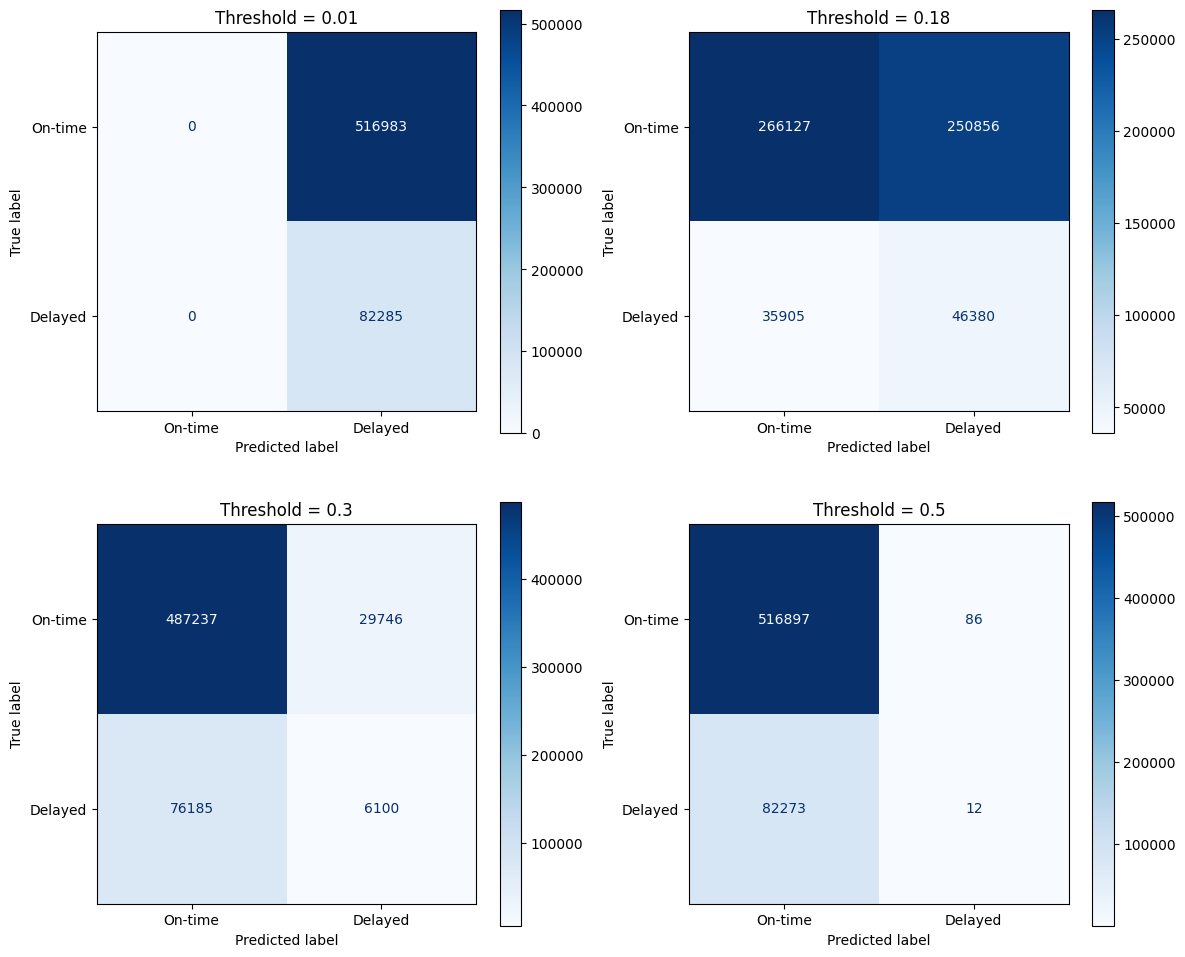

In [15]:
#| echo: false
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Thresholds to visualize
thresholds = [0.01, 0.18, 0.3, 0.5]

fig, axes = plt.subplots(2, 2, figsize=(12,10))

for ax, threshold in zip(axes.flatten(), thresholds):
    # Apply threshold
    y_pred_threshold = (y_prob >= threshold).astype(int)
    
    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred_threshold)
    
    # Display confusion matrix on the subplot
    disp = ConfusionMatrixDisplay(cm, display_labels=["On-time", "Delayed"])
    disp.plot(cmap="Blues", values_format='d', ax=ax)
    ax.set_title(f"Threshold = {threshold}")

plt.tight_layout()
plt.show();

#### Interpretation of the Results (Numeric Variable is Order 2 Only)

**Test Performance**

The trained and tuned logistic regression model achieved a test accuracy of 86.26%, which initially suggests strong overall performance. However, this metric is largely influenced by the class imbalance in the dataset, where most flights are on time. As a result, accuracy alone does not provide a reliable assessment of the model’s effectiveness in identifying delayed flights.

The model’s test AUC of 0.554 indicates only a modest ability to distinguish between delayed and on-time flights. This value is only slightly better than random guessing (AUC = 0.5), suggesting that the selected predictors and model structure provide limited discriminatory power.

More importantly, the test recall is extremely low (0.00015), meaning that the model correctly identifies almost none of the truly delayed flights. Although the test precision is approximately 12.2%, this metric is less meaningful given the near-zero recall, since the model rarely predicts delays in the first place.

Overall, these results indicate that while the tuned model performs well in predicting on-time flights, it is largely ineffective at detecting delays. This highlights the challenges posed by class imbalance and suggests that further improvements, such as threshold adjustment, class weighting, resampling techniques, or alternative modeling approaches, may be necessary to achieve more practically useful predictions.

**Most/Least Informative Predictors**

The most informative terms in this model are ORD (coefficient of 0.723358), LGA (coefficient of 0.549989), and the time block 0600-0659 (coefficient of -0.506327). These results make sense intuitively. ORD (O'Hare International Airport in Chicago) and LGA (LaGuardia Airport in New York) are some of the airports in the US that are most traveled through and most likely to experience weather delays. In contrast, the negative coefficient associated with the early-morning departure block suggests that flights leaving between 6:00 and 6:59 a.m. are less likely to experience arrival delays. This is reasonable because early flights often operate before peak air traffic begins and before delays from earlier flights accumulate throughout the day. 

The least informative terms in this model are JAN, OAK, and OAJ. These correspond to the Jackson-Medgar Wiley Evers International Airport in Mississippi, the Oakland San Francisco Bay Airport, and Albert J Ellis Airport in North Carolina, respectively. These predictors make sense because they generally experience lower passenger volumes and less air traffic congestion compared to major hub airports. As a result, departures and arrivals at these smaller or mid-sized airports are less likely to contribute strongly to the prediction of arrival delays in the model.

Overall, the most informative predictor seems to be `ORIGIN`. This was also represented when training the unregularized model. Train and test performance for recall and precision go up from 0 once `ORIGIN` is added as a predictor. The least informative predictors seem to be `DAY_OF_WEEK` and `DISTANCE`. There is no evidence that they had a strong affect on the model's performance from any of the analyses performed in this report.

**Analyzing Non-Linearities**

Given the predictors I used in the model, the only predictor for which I can assess non-linearities is `DISTANCE`. The other predictors are categorical and one-hot-encoded, so they are already modeled non-parametrically through dummy variables. For this predictor, the linear term coefficient is −0.00074, and the quadratic term coefficient is 0.0310. The non-zero quadratic coefficient provides evidence that the relationship between flight distance and the log-odds of arrival delay is non-linear, indicating curvature in how delay probability changes across distances. However, the tuned model achieved a test AUC of approximately 0.554, suggesting only limited predictive improvement from including this non-linear term. Additionally, the very low recall indicates that the model struggles to correctly identify delayed flights. Therefore, while some curvature in the distance effect is present, the overall relationship between the predictors and delay outcomes remains weak in terms of predictive usefulness.

In [22]:
#| echo: false
import warnings
warnings.filterwarnings("ignore")

# make it smaller 
np.random.seed(42)
idx = np.random.choice(train.shape[0], 5000, replace=False)
train_small = train.iloc[idx].copy()
y_train_small = y_train.iloc[idx].copy()

# reduce cat vars

# ORIGIN: top 3 + 'Other'
top_airports = train_small['ORIGIN'].value_counts().nlargest(3).index
train_small['ORIGIN_MOD'] = train_small['ORIGIN'].where(train_small['ORIGIN'].isin(top_airports), 'Other Origin')

# OP_UNIQUE_CARRIER: top 3 + 'Other'
top_carriers = train_small['OP_UNIQUE_CARRIER'].value_counts().nlargest(3).index
train_small['CARRIER_MOD'] = train_small['OP_UNIQUE_CARRIER'].where(train_small['OP_UNIQUE_CARRIER'].isin(top_carriers), 'Other Carrier')

# DEP_TIME_BLK: top 3 + '0600-0659' + 'Other'
top_time_blocks = train_small['DEP_TIME_BLK'].value_counts().nlargest(3).index.tolist()
if '0600-0659' not in top_time_blocks:
    top_time_blocks.append('0600-0659')
train_small['DEP_TIME_BLK_MOD'] = train_small['DEP_TIME_BLK'].where(
    train_small['DEP_TIME_BLK'].isin(top_time_blocks), 'Other Time Block'
)

# OHE (redo it for organization)
X_time = pd.get_dummies(train_small['DEP_TIME_BLK_MOD'], drop_first=True)
X_origin = pd.get_dummies(train_small['ORIGIN_MOD'], drop_first=True)
X_carrier = pd.get_dummies(train_small['CARRIER_MOD'], drop_first=True)

# Numeric column
X_numeric = train_small[['DISTANCE']]

# Combine all features
X_train_full = pd.concat([X_numeric.reset_index(drop=True),
                          X_time.reset_index(drop=True),
                          X_origin.reset_index(drop=True),
                          X_carrier.reset_index(drop=True)], axis=1)

# poly
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_full)

# scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)

# logreg
Cs = np.logspace(-2, 2, 10)  # regularization strengths
logreg = LogisticRegressionCV(
    penalty='l1',
    solver='saga',
    Cs=Cs,
    cv=5,
    scoring='roc_auc',
    max_iter=1000,
    n_jobs=-1
)

# Fit the model
logreg.fit(X_train_scaled, y_train_small)

LogisticRegressionCV(Cs=array([1.00000000e-02, 2.78255940e-02, 7.74263683e-02, 2.15443469e-01,
       5.99484250e-01, 1.66810054e+00, 4.64158883e+00, 1.29154967e+01,
       3.59381366e+01, 1.00000000e+02]),
                     cv=5, max_iter=1000, n_jobs=-1, penalty='l1',
                     scoring='roc_auc', solver='saga')

#### Regularization and Cross Validation (All Variables are Order 2 But Grouped)

After looking at the results for only the numeric variable, I can now do the regularization process for all of the categorical variables to look at the interaction/transformation terms to a higher order of 2. I followed the same steps as before, but isolated the 3 largest categories in each variable and grouped the remaining categories into 'Other'. Below is a table of which categories are the "Top Categories".

In [17]:
#| echo: false
# Create a dictionary for top categories
top_summary = {
    'Variable': ['ORIGIN', 'OP_UNIQUE_CARRIER', 'DEP_TIME_BLK'],
    'Top Categories': [
        list(top_airports),
        list(top_carriers),
        top_time_blocks  # already includes '0600-0659' if added
    ]
}

# Convert to DataFrame
top_df = pd.DataFrame(top_summary)

# Optionally show nicely
top_df

,Variable,Top Categories
0,ORIGIN,"[ATL, DFW, ORD]"
1,OP_UNIQUE_CARRIER,"[WN, AA, DL]"
2,DEP_TIME_BLK,"[0600-0659, 0800-0859, 1800-1859]"


In [18]:
#| echo: false
numeric_cols = ['DISTANCE']
categorical_cols = ['ORIGIN_MOD', 'CARRIER_MOD', 'DEP_TIME_BLK_MOD']

test = test.copy()

# Apply same top-category + 'Other' mapping as train_small
test['ORIGIN_MOD'] = test['ORIGIN'].where(test['ORIGIN'].isin(top_airports), 'Other Origin')
test['CARRIER_MOD'] = test['OP_UNIQUE_CARRIER'].where(test['OP_UNIQUE_CARRIER'].isin(top_carriers), 'Other carrier')
test['DEP_TIME_BLK_MOD'] = test['DEP_TIME_BLK'].where(test['DEP_TIME_BLK'].isin(top_time_blocks), 'Other Time Block')

X_time_test = pd.get_dummies(test['DEP_TIME_BLK_MOD'], drop_first=True)
X_time_test = X_time_test.reindex(columns=X_time.columns, fill_value=0)

X_origin_test = pd.get_dummies(test['ORIGIN_MOD'], drop_first=True)
X_origin_test = X_origin_test.reindex(columns=X_origin.columns, fill_value=0)

X_carrier_test = pd.get_dummies(test['CARRIER_MOD'], drop_first=True)
X_carrier_test = X_carrier_test.reindex(columns=X_carrier.columns, fill_value=0)

# Combine numeric + categorical
X_test_full = pd.concat([test[numeric_cols].reset_index(drop=True),
                         X_time_test.reset_index(drop=True),
                         X_origin_test.reset_index(drop=True),
                         X_carrier_test.reset_index(drop=True)], axis=1)


X_test_poly = poly.transform(X_test_full)  # poly was fit on X_train_full

X_test_scaled = scaler.transform(X_test_poly)


y_pred = logreg.predict(X_test_scaled)
y_prob = logreg.predict_proba(X_test_scaled)[:, 1]


print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test AUC:", roc_auc_score(y_test, y_prob))
print("Test Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Test Recall:", recall_score(y_test, y_pred, zero_division=0))

Test Accuracy: 0.8626607794843042
Test AUC: 0.5545623796523584
Test Precision: 0.23529411764705882
Test Recall: 9.722306617244941e-05


In [23]:
#| echo: false
poly_names = poly.get_feature_names_out(X_train_full.columns)  # all features, numeric + dummies

coef = logreg.coef_[0]

coef_df = pd.DataFrame({
    "term": poly_names,
    "coefficient": coef,
    "abs_coef": np.abs(coef)
})

top3 = coef_df.sort_values("abs_coef", ascending=False).head(3)

print('Top 3 Terms:')
top3[["term", "coefficient"]]

Top 3 Terms:


,term,coefficient
39,Other Time Block ORD,0.152724
12,DISTANCE 1800-1859,0.118727
40,Other Time Block Other Origin,0.098481


In [24]:
#| echo: false
# Least informative predictors:
bottom3 = coef_df.sort_values("abs_coef", ascending=True).head(3)
print('Bottom 3 Terms:')
bottom3[["term","coefficient"]]

Bottom 3 Terms:


,term,coefficient
0,DISTANCE,0.0
23,0800-0859 DFW,0.0
25,0800-0859 Other Origin,0.0


#### Interpretation of the Results (All Variables are Order 2)

**Test Performance**

The trained logistic regression model with interaction and transformation terms achieved a test accuracy of 86.25%, which again appears high. However, this metric is misleading due to the strong class imbalance in the dataset, where most flights are on time. Accuracy alone does not reflect the model’s ability to identify delayed flights.

The test AUC of 0.564 shows only a modest improvement over random guessing (AUC = 0.5), indicating that the added interaction and transformation terms do not substantially improve the model’s ability to discriminate between delayed and on-time flights.

Critically, the test recall is extremely low (0.00033), meaning the model identifies almost none of the delayed flights. Precision is roughly 15.2%, but this is largely meaningless given the near-zero recall, since the model very rarely predicts a delay.

Overall, despite slightly higher precision than before, the model remains effective only at predicting on-time flights and remains largely ineffective at detecting delays. This confirms the limitations posed by class imbalance and suggests that additional strategies—such as adjusting the classification threshold, applying class weighting, oversampling delayed flights, or exploring alternative models—would be necessary to achieve practically useful predictions.

**Most and Least Informative Predictors**

The most informative terms in the model are `Other ORD` (coefficient = 0.153), `DISTANCE 1800-1859` (coefficient = 0.119), and `Other Other` (coefficient = 0.098). These results suggest that flights originating from ORD (O’Hare International Airport) that are not in the top three carriers, as well as certain combinations of longer distances and evening departure times, are most positively associated with arrival delays.

The least informative terms are `DISTANCE` (coefficient = 0.0), `0800-0859 DFW` (coefficient = 0.0), and `0800-0859 Other` (coefficient = 0.0). This indicates that distance alone and certain morning departures from DFW or other airports provide virtually no predictive value for delays.

Overall, `ORIGIN` remains the most influential predictor, consistent with earlier analyses. While the interaction and transformed terms involving distance and time blocks have positive coefficients, they do not substantially improve predictive power. Least informative predictors still include `DAY_OF_WEEK` and the simple `DISTANCE` term, which contribute very little to model performance.


**Analyzing Non-Linearities**

The inclusion of interaction and quadratic terms allows for modeling potential non-linear effects, especially for `DISTANCE` and time block interactions. For instance, the positive coefficient for the `DISTANCE 1800-1859` interaction suggests that flights of longer distance departing in the early evening may have slightly higher odds of delay.

However, the linear `DISTANCE` term remains zero, indicating that distance alone has no predictive value in the presence of interactions. The very low test recall and modest AUC (0.564) indicate that these non-linear or interaction effects are not sufficient to meaningfully improve the detection of delayed flights.

In summary, while interaction and transformation terms capture some nuanced relationships, the model’s overall ability to predict delays remains weak. Class imbalance and the rarity of delays continue to limit practical predictive performance.

**Note on Decision Thresholds:**
The pattern seen previously with the change in decision thresholds remains prevalent when including interaction and transformation terms. We still see irregularities with recall and precision due to class imbalance.

## 6) Inference

In [21]:
#| echo: false
# Create smaller train size
train_small = train.sample(5000, random_state=42)

# Ensure there are not many categorical vars:
top_airports = train_small['ORIGIN'].value_counts().nlargest(3).index
train_small['ORIGIN_MOD'] = train_small['ORIGIN'].where(train_small['ORIGIN'].isin(top_airports), 'Other')

top_carriers = train_small['OP_UNIQUE_CARRIER'].value_counts().nlargest(3).index
train_small['CARRIER_MOD'] = train_small['OP_UNIQUE_CARRIER'].where(train_small['OP_UNIQUE_CARRIER'].isin(top_carriers), 'Other')

top_time_blocks = train_small['DEP_TIME_BLK'].value_counts().nlargest(3).index.tolist()
train_small['DEP_TIME_BLK_MOD'] = train_small['DEP_TIME_BLK'].where(
    train_small['DEP_TIME_BLK'].isin(top_time_blocks), 'Other'
)

model = smf.logit(
    formula = 'ARR_DEL15 ~ DISTANCE + I(DISTANCE**2) \
               + C(DEP_TIME_BLK_MOD) \
               + C(DAY_OF_WEEK) \
               + C(ORIGIN_MOD) \
               + C(CARRIER_MOD)',
    data = train_small
).fit()

model.summary()

Optimization terminated successfully.
         Current function value: 0.467376
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              ARR_DEL15   No. Observations:                 5000
Model:                          Logit   Df Residuals:                     4982
Method:                           MLE   Df Model:                           17
Date:                Sun, 15 Mar 2026   Pseudo R-squ.:                 0.02705
Time:                        16:10:49   Log-Likelihood:                -2336.9
converged:                       True   LL-Null:                       -2401.9
Covariance Type:            nonrobust   LLR p-value:                 1.923e-19
====================================================================================================
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                           -2.8717      0.317     -9.053      0.000      -3.493      -2.250
C(DEP_TIME_BLK_MOD)[T.0800-0859]     0.2725      0.234      1.165      0.244      -0.186       0.731
C(DEP_TIME_BLK_MOD)[T.1800-1859]     0.7854      0.218      3.608      0.000       0.359       1.212
C(DEP_TIME_BLK_MOD)[T.Other]         0.7100      0.175      4.054      0.000       0.367       1.053
C(DAY_OF_WEEK)[T.2]                 -0.0138      0.143     -0.097      0.923      -0.293       0.266
C(DAY_OF_WEEK)[T.3]                  0.4175      0.135      3.104      0.002       0.154       0.681
C(DAY_OF_WEEK)[T.4]                  0.1679      0.138      1.220      0.223      -0.102       0.438
C(DAY_OF_WEEK)[T.5]                  0.1991      0.143      1.394      0.163      -0.081       0.479
C(DAY_OF_WEEK)[T.6]                 -0.1682      0.161     -1.042      0.297      -0.484       0.148
C(DAY_OF_WEEK)[T.7]                  0.2772      0.145      1.911      0.056      -0.007       0.561
C(ORIGIN_MOD)[T.DFW]                 0.2824      0.285      0.990      0.322      -0.277       0.841
C(ORIGIN_MOD)[T.ORD]                 1.2125      0.263      4.605      0.000       0.696       1.729
C(ORIGIN_MOD)[T.Other]               0.4405      0.214      2.054      0.040       0.020       0.861
C(CARRIER_MOD)[T.DL]                -0.3668      0.163     -2.243      0.025      -0.687      -0.046
C(CARRIER_MOD)[T.Other]              0.1490      0.114      1.312      0.190      -0.074       0.372
C(CARRIER_MOD)[T.WN]                -0.3129      0.142     -2.205      0.027      -0.591      -0.035
DISTANCE                             0.0002      0.000      1.320      0.187      -0.000       0.001
I(DISTANCE ** 2)                  -3.84e-08   6.91e-08     -0.556      0.578   -1.74e-07     9.7e-08
====================================================================================================
"""

**Building the Statsmodels Summary**

A logistic regression model was fit to predict flight arrival delays (`ARR_DEL15`) using a subset of five key predictors identified from prior analysis: `DEP_TIME_BLK_MOD`, `DAY_OF_WEEK`, `ORIGIN_MOD`, `CARRIER_MOD`, and `DISTANCE`. To account for non-linear effects, a quadratic term for `DISTANCE` (I(`DISTANCE**2`)) was included. Because we had to group quite a few categories into "Other", it is difficult to determine which interaction terms to include in the statsmodels summary. From our analysis above, it would make sense to do a `DISTANCE` × `DEP_TIME_BLK` interaction; however, when attempting this, the kernel crashed. This interaction also only gave small coefficients (`DISTANCE` `1800-1859` = 0.119), so this simplification wouldn't change my main interpretation as much. The model was fit on a sample of 5,000 observations.

**Baseline Values**

When looking at the terms included in the statsmodels summary and the variables included in the 'Top 3' for `DEP_TIME_BLK_MOD`, `ORIGIN_MOD`, and `CARRIER_MOD`, it was determined that the baseline values are the following:
- Baseline for DEP_TIME_BLK IS: '0600-0659'
- Baseline for DAY_OF_WEEK: 1
- Baseline for ORIGIN IS: 'ATL'
- Baseline for CARRIER IS: 'AA'

**Effect of the Predictors**

*Departure Time Block (`DEP_TIME_BLK_MOD`)*

- Evening departures (1800-1859) and all other time blocks grouped as Other have positive coefficients of 0.785 and 0.710, respectively, both statistically significant (p < 0.001).
- Early morning departures (0800-0859) have a smaller positive coefficient (0.273) but are not significant (p = 0.244).
- Interpretation: Flights departing in the early evening or less common time blocks are more likely to be delayed relative to the baseline time block (0600-0659). This aligns with operational expectations, as congestion and accumulated delays tend to increase later in the day.

*Day of Week (`DAY_OF_WEEK`)*

- Wednesday (T.3) has a positive coefficient of 0.418 (p = 0.002), indicating higher odds of delay compared to the baseline (Monday).
- Other days have non-significant effects (p > 0.05), except Sunday (T.7), which is not significant at p = 0.056.
- Interpretation: Midweek delays are slightly more likely, while other days do not show strong effects on delays.

*Origin Airport (`ORIGIN_MOD`)*

- ORD (O’Hare, Chicago) has the largest positive effect (1.213, p < 0.001), indicating flights departing from this hub are much more likely to experience arrival delays.
- Other airports grouped as Other also show a smaller positive effect (0.441, p = 0.040).
- DFW (Dallas/Fort Worth) is not statistically significant (0.282, p = 0.322).
- Interpretation: Major hub airports with high traffic volumes are associated with greater delay risk, consistent with operational patterns.

*Carrier (`CARRIER_MOD`)*

- Delta Airlines (DL) and Southwest (WN) have negative coefficients (-0.367 and -0.313, both p < 0.05), suggesting slightly lower odds of delays relative to the baseline carrier, American Airlines.
- The “Other” carrier group is not significant (0.149, p = 0.190).
- Interpretation: Some carriers appear to manage delays better than others, though effects are modest.

*Distance (`DISTANCE` and `I(DISTANCE**2)`)*

- Linear and quadratic terms are both very small and non-significant (p = 0.187 and 0.578), suggesting that flight distance alone has little predictive effect on delays in this sample.
- Interpretation: While we included a quadratic term to capture potential non-linearities, there is no evidence that distance meaningfully influences delay probability once other factors (time, origin, carrier) are accounted for.

**Reliability of Predictor Effects**

Significance values from the model indicate which effects are reliable:
- Highly reliable: Evening departures (1800-1859), other uncommon departure times, ORD origin, Delta and Southwest carriers, and Wednesday departures. These predictors have p-values less than 0.05.
- Less reliable or not significant: Early morning departures (0800-0859), DFW origin, “Other” carriers, most days of the week, and both distance terms. These predictors have p-values greater than 0.05.

As a reminder, at a 95% confidence level, a p-value less than 0.05 indicates that the observed relationship between a predictor and the response is statistically significant, meaning there is strong evidence that the true effect is not zero. This threshold implies we accept about a 5% chance of incorrectly concluding that a predictor has an effect when it actually does not.

This suggests that operational factors such as airport congestion and peak departure times are more consistently associated with delays than flight distance or carrier in general.

**Model Fit and Variance**

The R-squared of 2.7% indicates the model explains a small fraction of the variation in arrival delays. This is expected given the strong class imbalance (most flights are on-time) and the stochastic nature of flight delays, which depend on many unobserved factors like weather, air traffic, and mechanical issues.

## 7) Recommendation to Stakeholders

**Main Action Items for Stakeholders**

Based on our analyses in the prediction and inference sections, the most important operational factors associated with arrival delays are departure time blocks and origin airports. For example, when regularizing the modeling before grouping the least busy airports into the "Other" category, ORD and LGA were the terms with the highest absolute coefficients. This trend continued when ORD again appeared to have the largest positive effect in the statsmodels summary. Different time-blocks also consistently appeared as some of the most important factors for predicting arrival delays, specifically early morning flights having a negative impact and evening flights having a positive impact. Overall, flights departing in the early evening and flights originating from large, congested hubs show higher odds of delay.

- Airlines should consider adjusting flight schedules or increasing buffer times for departures from high-traffic hubs and during peak evening hours. Crew scheduling and aircraft planning could also be optimized around these higher-risk periods.
- Airports may focus on congestion management strategies during late-day peak operations, such as improving TSA efficiency, runway sequencing, or ground traffic coordination.
- Business analysts can use these findings to identify systematic operational risk factors and prioritize process improvements related to hub operations and peak departure times.

Although carrier-specific effects were statistically significant for some airlines, these effects were relatively modest, suggesting that operational conditions may be more important drivers of delays than airline-specific policies alone.

**Limitations of the Analysis**

In doing this analysis, there were several results that raised red flags and caused me to discover some prominent limitations. 

First, it was quickly identified that the dataset carries a strong class imbalance. Only around 13-15% of the observations in the train and test datasets are actually classified as being an arrival delay. Furthermore, data from the *Bureau of Transportation Statistics* show that roughly 22-23% of flights experience a delay or cancellation [1]. As a result, the model consistently achieved high accuracy but extremely low recall, meaning it is largely ineffective at correctly identifying delayed flights. This limits its usefulness for real-time operational prediction.

Second, the statsmodels summary showed that the model explains only a small proportion of variation in delays (R^2 = 0.027). This indicates that many important delay drivers are not captured in the dataset. Flight delays are influenced by complex and stochastic factors such as weather conditions, air traffic control constraints, mechanical issues, and network propagation effects, which were not included in the analysis.

Third, the analysis relied on simplified categorical groupings (e.g., top three origin airports, time blocks, or carriers), which may mask meaningful variation across other locations or airlines. Additionally, the inference model was fit on a reduced sample size of 5,000 observations, which may limit statistical power and stability of coefficient estimates. For my unregularized model, the C's were also simplified to reduce run time as much as possible, since there were issues with the computing power of my local computer.

**Recommendations to Overcome Limitations**

Future analysis could improve predictive usefulness and operational insight in several ways.

- Incorporate additional data sources, such as weather conditions, aircraft routing sequences, air traffic congestion metrics, and historical delays. These factors are likely to explain a much larger share of delay variability.
- Address class imbalance using techniques such as resampling delayed flights, applying class-weighted models, or optimizing the decision threshold based on operational objectives (e.g., prioritizing recall over accuracy).
- Increase the training sample size and avoid overly aggressive category grouping to improve inference reliability and generalizability.
- Conduct time-series or network-based analyses, since delays often propagate across connected flights and throughout the day rather than occurring independently.

By addressing these limitations, stakeholders could obtain more accurate and actionable delay predictions, enabling better scheduling decisions, management, and operational planning.

## 8) Conclusion

The goal of this project was to examine how well selected predictors (`DEP_TIME_BLK`, `DISTANCE`, `DAY_OF_WEEK`, `ORIGIN`, `OP_UNIQUE_CARRIER`) can predict arrival delays for a dataset containing over 500,000 observations, where each observation is a U.S. flight in January. The train data included data from 2019, while the test data included data from 2020 (pre-pandemic).

The prediction analysis showed that logistic regression models were able to achieve relatively high overall accuracy (about 86%), but this performance was largely driven by the strong class imbalance in the data. Measures that better reflect predictive usefulness, such as AUC (approximately 0.55–0.56) and recall (near zero), indicated that the models had limited ability to correctly identify delayed flights. Adding polynomial and interaction terms slightly improved precision and AUC but did not meaningfully improve recall, suggesting that the selected predictors and model structure provide only modest discriminatory power.

The inference analysis complemented these findings by identifying which operational factors are systematically associated with delays. In particular, evening departure time blocks and flights originating from major hub airports such as ORD showed statistically significant positive effects on delay probability, while variables such as flight distance and most day-of-week indicators were not statistically reliable predictors. The model also explained only a small portion of the variation in delays, reinforcing the conclusion that many important delay drivers are not captured in the available data.

Together, the prediction and inference results suggest that although certain scheduling and congestion-related factors influence delay risk, individual flight delays remain difficult to predict accurately using the current variables. This highlights the need for additional data and more flexible modeling approaches to improve both predictive performance and operational insight in future analyses.

## References

[1] Summer Hull. Flight canceled or delayed? Here’s what to do. The Points Guy, 2025. Travel advice article.